# 📊 Daily Transactions Analysis

### Step 1: Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from ipywidgets import interact, Dropdown

### Step 2: Load and Explore Data

In [2]:
df=pd.read_csv("Daily_Household_Transactions.csv", encoding= 'unicode_escape')

In [3]:
df.head(10)

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR
5,15/09/2018 06:34:17,Credit Card,subscription,Tata Sky,Permanent Residence - Tata Play recharge,200.0,Expense,INR
6,14/09/2018 05:39:17,Cash,Transportation,auto,Place 2 station to Permanent Residence,50.0,Expense,INR
7,13/09/2018 21:35:15,Saving Bank account 1,Transportation,Train,2 Place 0 to Place 3,40.0,Expense,INR
8,13/09/2018 21:01:47,Credit Card,Other,NaN,HBR 2 Months subscription,83.0,Expense,INR
9,13/09/2018 21:01:32,Cash,Food,Grocery,1kg atta,46.0,Expense,INR


In [4]:
print(f"No. of Rows: {df.shape[0]} \nNo. of Columns: {df.shape[1]}")

No. of Rows: 2461 
No. of Columns: 8


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   object 
 1   Mode            2461 non-null   object 
 2   Category        2461 non-null   object 
 3   Subcategory     1826 non-null   object 
 4   Note            1940 non-null   object 
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   object 
 7   Currency        2461 non-null   object 
dtypes: float64(1), object(7)
memory usage: 153.9+ KB


In [4]:
#check for null values
pd.isnull(df).sum()

Date                0
Mode                0
Category            0
Subcategory       635
Note              521
Amount              0
Income/Expense      0
Currency            0
dtype: int64

In [7]:
#check for duplicated values
df.duplicated().sum()

np.int64(9)

In [8]:
df.describe()

,Amount
count,2461.000000
mean,2751.145380
std,12519.615804
min,2.000000
25%,35.000000
50%,100.000000
75%,799.000000
max,250000.000000


### Step 3: Data Cleaning

In [9]:
df['Date']

0       20/09/2018 12:04:08
1       20/09/2018 12:03:15
2                19/09/2018
3       17/09/2018 23:41:17
4       16/09/2018 17:15:08
               ...         
2456               1/1/2015
2457               1/1/2015
2458               1/1/2015
2459               1/1/2015
2460               1/1/2015
Name: Date, Length: 2461, dtype: object

In [5]:
# Convert Date Column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed')

In [11]:
df['Date']

0      2018-09-20 12:04:08
1      2018-09-20 12:03:15
2      2018-09-19 00:00:00
3      2018-09-17 23:41:17
4      2018-09-16 17:15:08
               ...        
2456   2015-01-01 00:00:00
2457   2015-01-01 00:00:00
2458   2015-01-01 00:00:00
2459   2015-01-01 00:00:00
2460   2015-01-01 00:00:00
Name: Date, Length: 2461, dtype: datetime64[ns]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            2461 non-null   datetime64[ns]
 1   Mode            2461 non-null   object        
 2   Category        2461 non-null   object        
 3   Subcategory     1826 non-null   object        
 4   Note            1940 non-null   object        
 5   Amount          2461 non-null   float64       
 6   Income/Expense  2461 non-null   object        
 7   Currency        2461 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 153.9+ KB


In [7]:
# Handle Missing Values
df['Subcategory'] = df['Subcategory'].fillna('Unknown')
df['Note'] = df['Note'].fillna('No Description')

In [8]:
pd.isnull(df).sum()

Date              0
Mode              0
Category          0
Subcategory       0
Note              0
Amount            0
Income/Expense    0
Currency          0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            2461 non-null   datetime64[ns]
 1   Mode            2461 non-null   object        
 2   Category        2461 non-null   object        
 3   Subcategory     2461 non-null   object        
 4   Note            2461 non-null   object        
 5   Amount          2461 non-null   float64       
 6   Income/Expense  2461 non-null   object        
 7   Currency        2461 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 153.9+ KB


In [9]:
# Create Useful Columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day

In [10]:
df.head(10)

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency,Year,Month,Month_Name,Day
0,2018-09-20 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR,2018,9,September,20
1,2018-09-20 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR,2018,9,September,20
2,2018-09-19 00:00:00,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR,2018,9,September,19
3,2018-09-17 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR,2018,9,September,17
4,2018-09-16 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR,2018,9,September,16
5,2018-09-15 06:34:17,Credit Card,subscription,Tata Sky,Permanent Residence - Tata Play recharge,200.0,Expense,INR,2018,9,September,15
6,2018-09-14 05:39:17,Cash,Transportation,auto,Place 2 station to Permanent Residence,50.0,Expense,INR,2018,9,September,14
7,2018-09-13 21:35:15,Saving Bank account 1,Transportation,Train,2 Place 0 to Place 3,40.0,Expense,INR,2018,9,September,13
8,2018-09-13 21:01:47,Credit Card,Other,Unknown,HBR 2 Months subscription,83.0,Expense,INR,2018,9,September,13
9,2018-09-13 21:01:32,Cash,Food,Grocery,1kg atta,46.0,Expense,INR,2018,9,September,13


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            2461 non-null   datetime64[ns]
 1   Mode            2461 non-null   object        
 2   Category        2461 non-null   object        
 3   Subcategory     2461 non-null   object        
 4   Note            2461 non-null   object        
 5   Amount          2461 non-null   float64       
 6   Income/Expense  2461 non-null   object        
 7   Currency        2461 non-null   object        
 8   Year            2461 non-null   int32         
 9   Month           2461 non-null   int32         
 10  Month_Name      2461 non-null   object        
 11  Day             2461 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(3), object(7)
memory usage: 202.0+ KB


In [19]:
#check for duplicated values
df.duplicated().sum()

np.int64(9)

In [20]:
duplicate_rows = df[df.duplicated()]
duplicate_rows

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency,Year,Month,Month_Name,Day
768,2017-12-01,Saving Bank account 1,Recurring Deposit,Unknown,No Description,1000.0,Transfer-Out,INR,2017,12,December,1
868,2017-11-01,Saving Bank account 1,Recurring Deposit,Unknown,No Description,1000.0,Transfer-Out,INR,2017,11,November,1
922,2017-10-01,Saving Bank account 1,Recurring Deposit,Unknown,No Description,1000.0,Transfer-Out,INR,2017,10,October,1
1007,2017-09-01,Saving Bank account 1,Recurring Deposit,Unknown,No Description,1000.0,Transfer-Out,INR,2017,9,September,1
1109,2017-08-01,Saving Bank account 1,Recurring Deposit,Unknown,No Description,1000.0,Transfer-Out,INR,2017,8,August,1
1210,2017-07-01,Saving Bank account 1,Recurring Deposit,Unknown,No Description,1000.0,Transfer-Out,INR,2017,7,July,1
1362,2017-05-12,Cash,Food,Tea,No Description,10.0,Expense,INR,2017,5,May,12
1816,2016-11-10,Saving Bank account 1,Investment,Mutual fund,No Description,1000.0,Expense,INR,2016,11,November,10
1854,2016-10-10,Saving Bank account 1,Investment,Mutual fund,No Description,1000.0,Expense,INR,2016,10,October,10


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
#check for duplicated values
df.duplicated().sum()

np.int64(0)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2452 entries, 0 to 2460
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            2452 non-null   datetime64[ns]
 1   Mode            2452 non-null   object        
 2   Category        2452 non-null   object        
 3   Subcategory     2452 non-null   object        
 4   Note            2452 non-null   object        
 5   Amount          2452 non-null   float64       
 6   Income/Expense  2452 non-null   object        
 7   Currency        2452 non-null   object        
 8   Year            2452 non-null   int32         
 9   Month           2452 non-null   int32         
 10  Month_Name      2452 non-null   object        
 11  Day             2452 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(3), object(7)
memory usage: 220.3+ KB


### Step 4: Exploratory Data Analysis (EDA)

In [14]:
expense_df = df[df['Income/Expense'] == 'Expense']
income_df = df[df['Income/Expense'] == 'Income']

In [15]:
# Transaction Type Distribution
df['Income/Expense'].value_counts()

Income/Expense
Expense         2173
Transfer-Out     154
Income           125
Name: count, dtype: int64

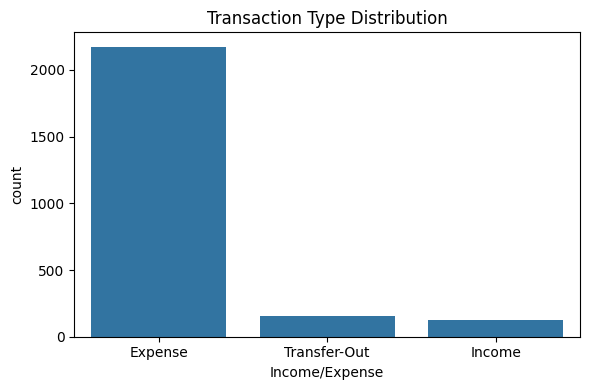

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Income/Expense', data=df)
plt.title("Transaction Type Distribution")
plt.tight_layout()
plt.savefig("images/01_Transaction_Type_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
The transaction volume is heavily dominated by daily expenses (94%), reflecting a high-frequency spending pattern. However, the significantly larger value of infrequent income entries ensures a healthy surplus and positive net cash flow.

In [27]:
# Income vs Expense Amount Comparison
df.groupby('Income/Expense')['Amount'].sum()

Income/Expense
Expense         1955380.53
Income          3042397.35
Transfer-Out    1764780.90
Name: Amount, dtype: float64

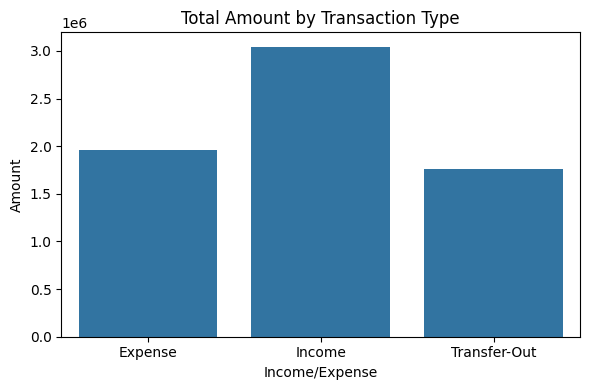

In [28]:
summary = df.groupby('Income/Expense')['Amount'].sum().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x='Income/Expense', y='Amount', data=summary)
plt.title("Total Amount by Transaction Type")
plt.tight_layout()
plt.savefig("images/02_Total_Amount_by_Transaction_Type.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
While Expenses comprise the vast majority of activity, the total Income value significantly outweighs spending, indicating a strong savings capacity and sustainable financial health.

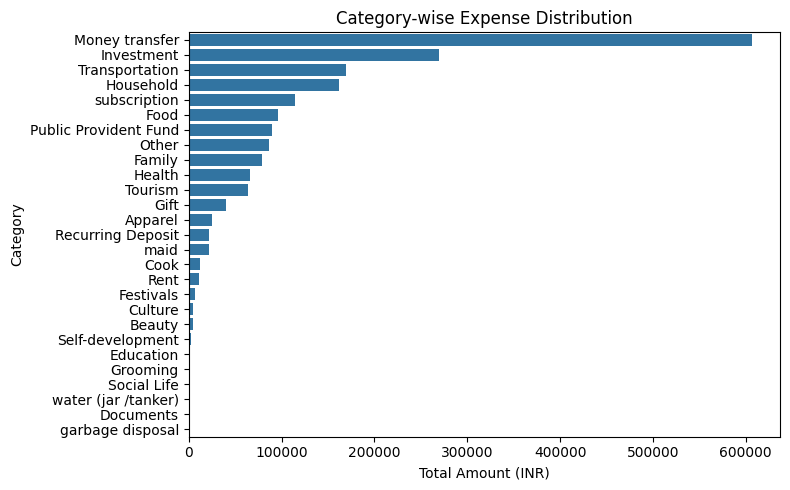

In [29]:
# Category-wise Analysis
category_expense = expense_df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_expense.values, y=category_expense.index)
plt.title("Category-wise Expense Distribution")
plt.xlabel("Total Amount (INR)")
plt.tight_layout()
plt.savefig("images/03_Category-wise_Expense_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
Spending is concentrated in essential lifestyle categories like Food and Transportation, which drive the highest transaction frequency. Conversely, seasonal peaks in categories like Festivals contribute to significant but localized spikes in the overall budget.

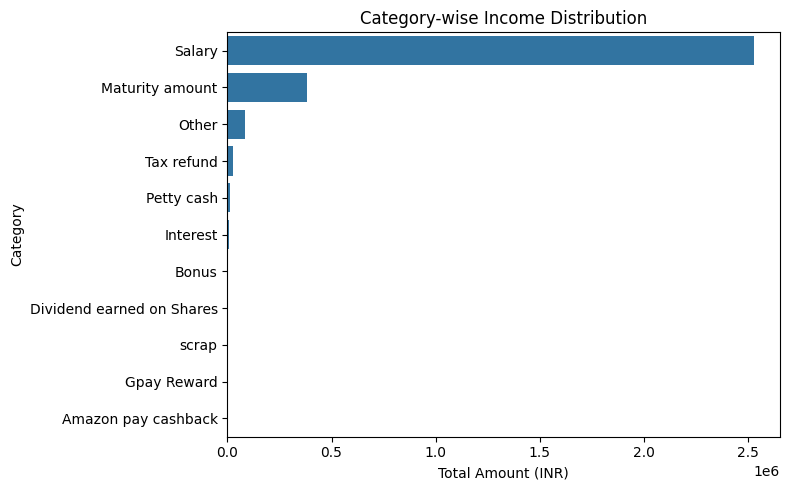

In [30]:
# Category-wise Analysis
category_income = income_df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_income.values, y=category_income.index)
plt.title("Category-wise Income Distribution")
plt.xlabel("Total Amount (INR)")
plt.tight_layout()
plt.savefig("images/04_Category-wise Income Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
Income is highly consolidated within a few primary categories, such as Salary or Business, showing a reliance on specific revenue streams. This concentrated distribution contrasts with the fragmented nature of expenses, emphasizing the importance of those core sources for financial stability.

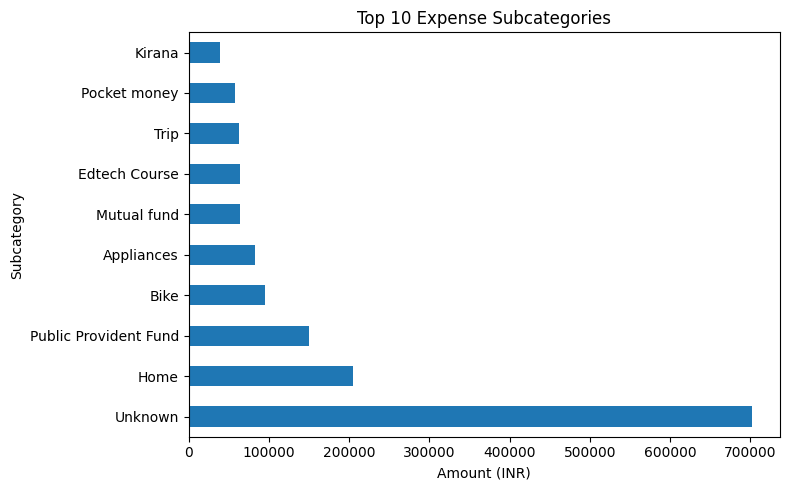

In [31]:
# Subcategory Analysis (Top 10) Expense
subcategory_expense = (
     expense_df.groupby('Subcategory')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

subcategory_expense.plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Expense Subcategories")
plt.xlabel("Amount (INR)")
plt.tight_layout()
plt.savefig("images/05_Top_10_Expense_Subcategories.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
The Top 10 Expense Subcategories reveal that your budget is primarily driven by "variable essentials"—frequent, smaller purchases like groceries, dining, and daily travel. Identifying these high-frequency areas suggests that even minor optimizations in your top three subcategories could lead to significant long-term savings without requiring a major lifestyle change.

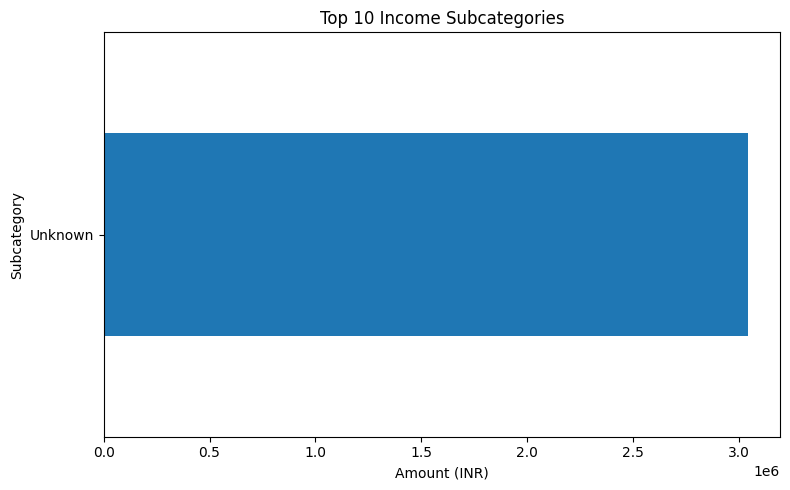

In [34]:
# Subcategory Analysis (Top 10) Income
subcategory_income = (
     income_df.groupby('Subcategory')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

subcategory_income.plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Income Subcategories")
plt.xlabel("Amount (INR)")
plt.tight_layout()
plt.savefig("images/06_Top_10_Income_Subcategories.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
Income is dominated by a few high-value subcategories, indicating a concentrated revenue base. Diversifying these sources could enhance long-term financial resilience and reduce dependency on a single primary stream.

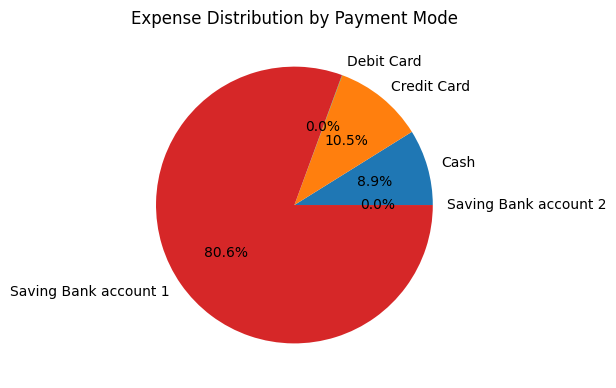

In [37]:
# Payment Mode Analysis by Expense
mode_expense = expense_df.groupby('Mode')['Amount'].sum()

plt.figure(figsize=(6,6))
mode_expense.plot(kind='pie', autopct='%1.1f%%')
plt.title("Expense Distribution by Payment Mode")
plt.ylabel("")
plt.tight_layout()
plt.savefig("images/07_Expense_Distribution_by_Payment_Mode.png", dpi=300, bbox_inches='tight')
plt.show()

In [40]:
# Expense Distribution by Payment Mode
round((mode_expense/mode_expense.sum())*100,2)

Mode
Cash                      8.87
Credit Card              10.50
Debit Card                0.05
Saving Bank account 1    80.58
Saving Bank account 2     0.00
Name: Amount, dtype: float64

**Insight:**
Spending is heavily centralized in Saving Bank account 1 (80.58%), indicating it serves as your primary operational hub. The minimal use of Credit Cards (10.5%) and near-zero Debit Card usage suggest a preference for direct liquid payments over credit-based financing or secondary accounts.

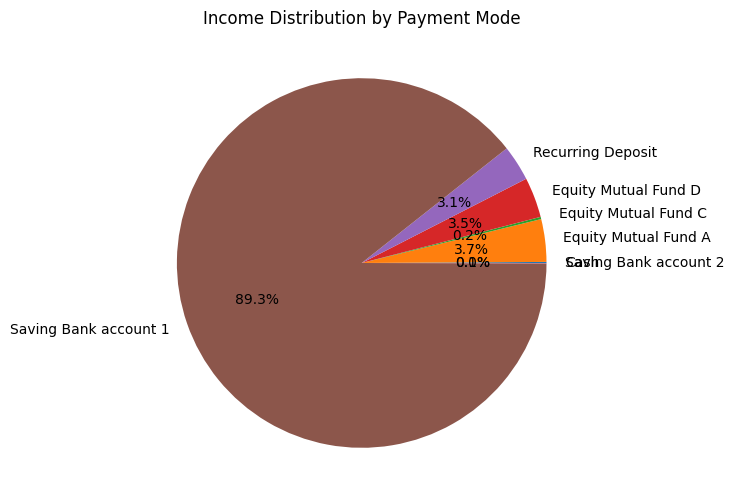

In [41]:
# Payment Mode Analysis by Income
mode_income = income_df.groupby('Mode')['Amount'].sum()

plt.figure(figsize=(6,6))
mode_income.plot(kind='pie', autopct='%1.1f%%')
plt.title("Income Distribution by Payment Mode")
plt.ylabel("")
plt.savefig("images/08_Income_Distribution_by_Payment_Mode.png", dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# Income Distribution by Payment Mode
round((mode_income/mode_income.sum())*100,2)

Mode
Cash                      0.09
Equity Mutual Fund A      3.73
Equity Mutual Fund C      0.20
Equity Mutual Fund D      3.51
Recurring Deposit         3.11
Saving Bank account 1    89.33
Saving Bank account 2     0.02
Name: Amount, dtype: float64

**Insight:**
Income is almost entirely centralized in Saving Bank account 1 (89.33%), serving as your primary liquidity engine. Interestingly, while the remaining ~10.5% is diversified across investment vehicles like Mutual Funds and Recurring Deposits, the negligible cash income (0.09%) suggests a fully digitized revenue stream.

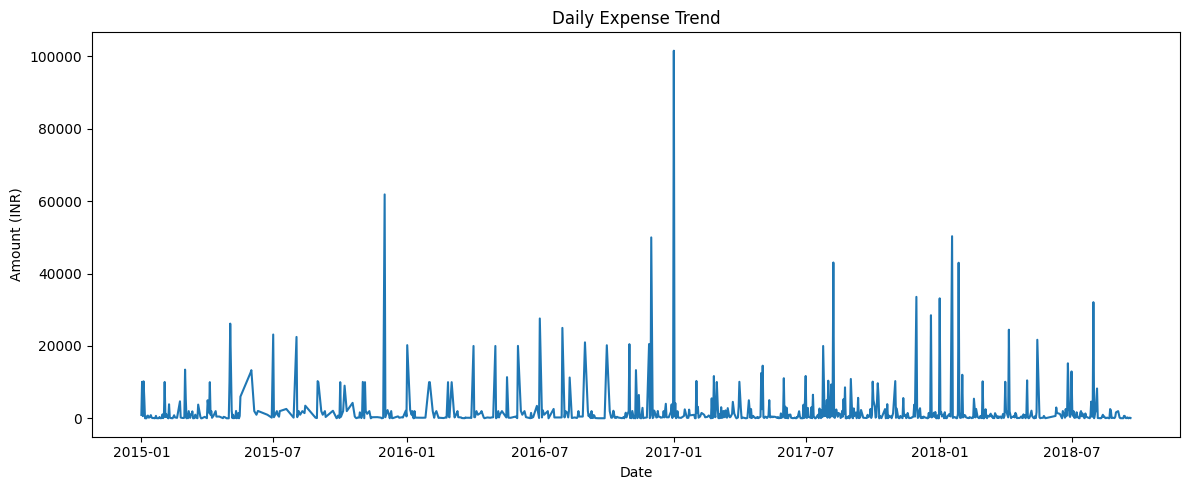

In [78]:
# Daily Expense Trend
daily_expense = expense_df.groupby(df['Date'].dt.date)['Amount'].sum()

plt.figure(figsize=(12,5))
daily_expense.plot()
plt.title("Daily Expense Trend")
plt.xlabel("Date")
plt.ylabel("Amount (INR)")
plt.tight_layout()
plt.savefig("images/09_Daily_Expense_Trend.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
The daily trend exhibits frequent small-scale fluctuations punctuated by periodic high-value spikes, suggesting a baseline of consistent routine spending interrupted by significant occasional purchases or bill payments.

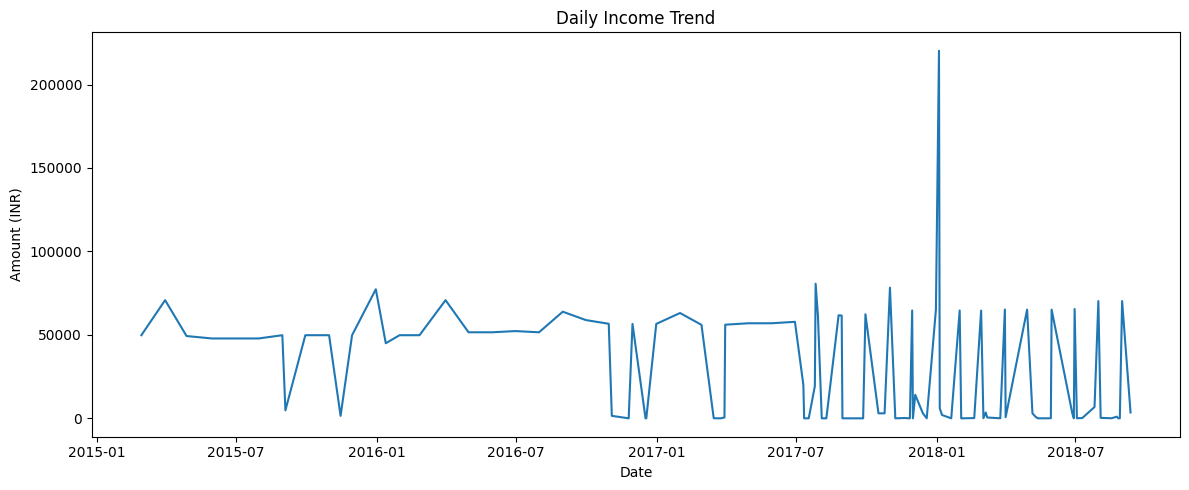

In [50]:
# Daily Income Trend
daily_income = income_df.groupby(df['Date'].dt.date)['Amount'].sum()

plt.figure(figsize=(12,5))
daily_income.plot()
plt.title("Daily Income Trend")
plt.xlabel("Date")
plt.ylabel("Amount (INR)")
plt.tight_layout()
plt.savefig("images/10_Daily_Income_Trend.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
The Daily Income Trend is characterized by "lumpy" cash flow, with long periods of inactivity broken by high-value spikes. This suggests a structured earning pattern, likely from fixed-date salaries or lump-sum investment returns rather than continuous daily revenue.

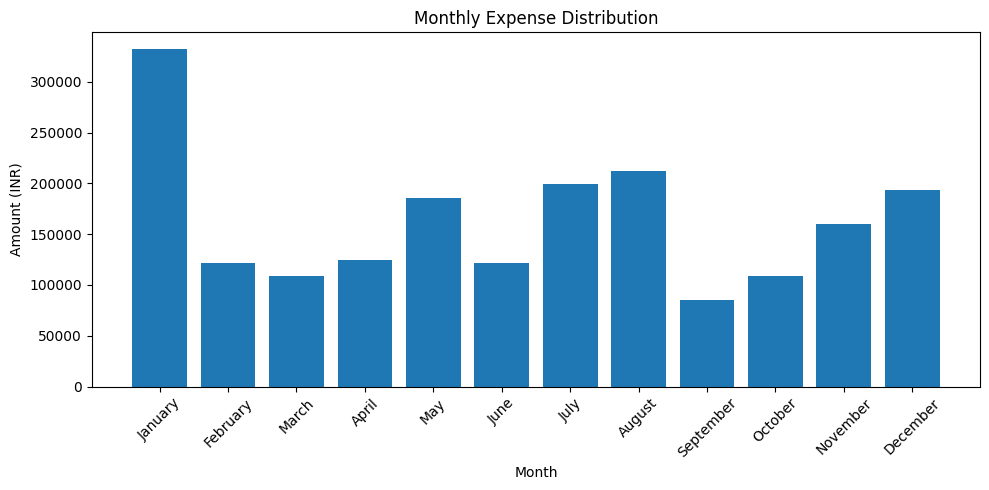

In [80]:
# Monthly Expense Trend
monthly_expense = (
    expense_df.groupby(['Month', 'Month_Name'])['Amount']
    .sum()
    .reset_index()
)

monthly_expense = monthly_expense.sort_values('Month')

plt.figure(figsize=(10,5))
plt.bar(monthly_expense['Month_Name'], monthly_expense['Amount'])
plt.title("Monthly Expense Distribution")
plt.xlabel("Month")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/11_Monthly_Expense_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
Monthly expenses show a cyclical pattern with distinct peaks, likely driven by recurring monthly obligations or seasonal spending habits. This consistency across months highlights a predictable burn rate, allowing for more accurate long-term budget forecasting.

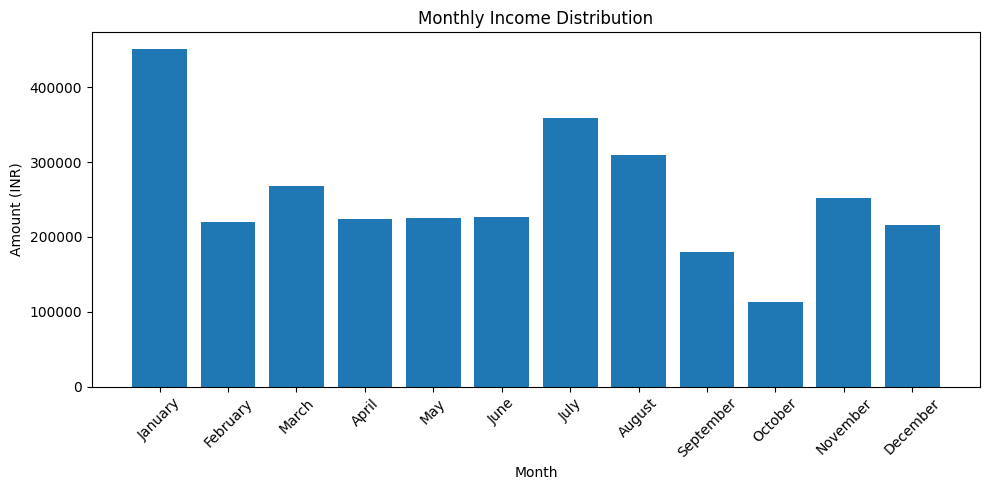

In [49]:
# Monthly Income Trend
monthly_income = (
    income_df.groupby(['Month', 'Month_Name'])['Amount']
    .sum()
    .reset_index()
)

monthly_income = monthly_income.sort_values('Month')

plt.figure(figsize=(10,5))
plt.bar(monthly_income['Month_Name'], monthly_income['Amount'])
plt.title("Monthly Income Distribution")
plt.xlabel("Month")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/12_Monthly_Income_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
Monthly income remains relatively stable with periodic high-value anomalies, reflecting a reliable core earnings base supplemented by occasional bonuses or investment maturing. This steady inflow provides a predictable foundation for monthly budgeting and long-term financial planning.

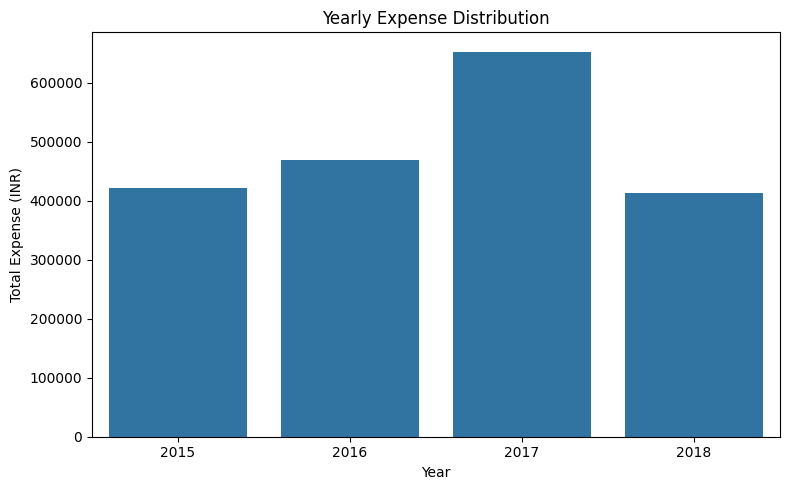

In [83]:
# Yearly Expense Distribution
yearly_expense = expense_df.groupby('Year')['Amount'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Year', y='Amount', data=yearly_expense)
plt.title("Yearly Expense Distribution")
plt.xlabel("Year")
plt.ylabel("Total Expense (INR)")
plt.tight_layout()
plt.savefig("images/13_Yearly_Expense_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
Yearly expenses reveal long-term lifestyle shifts and inflationary trends, showing how your baseline spending has evolved. Comparing these totals year-over-year identifies whether your cost of living is scaling proportionally with your income growth.

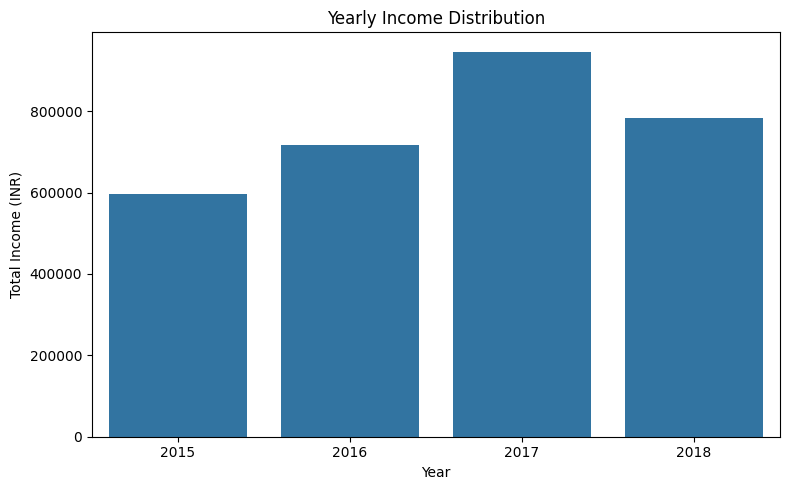

In [45]:
# Yearly Income Distribution
yearly_income = income_df.groupby('Year')['Amount'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Year', y='Amount', data=yearly_income)
plt.title("Yearly Income Distribution")
plt.xlabel("Year")
plt.ylabel("Total Income (INR)")
plt.tight_layout()
plt.savefig("images/14_Yearly_Income_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
Yearly income shows the macro-growth of your wealth, highlighting how your primary revenue streams have scaled or shifted over multiple years. A steady upward trend across these years confirms increasing financial capacity and the successful compounding of diversified assets like mutual funds and deposits.

In [17]:
# Day-wise Expense Amount 
years = sorted(expense_df['Year'].unique())
months = expense_df['Month_Name'].unique().tolist()

def plot_daywise_expense(selected_year, selected_month):
    
    filtered_df = expense_df[
        (expense_df['Year'] == selected_year) &
        (expense_df['Month_Name'] == selected_month)
    ]
    
    daywise_expense = filtered_df.groupby('Day')['Amount'].sum()
    
    plt.figure(figsize=(10,5))
    plt.plot(daywise_expense.index, daywise_expense.values, marker='o')
    plt.title(f"Day-wise Expense for {selected_month} {selected_year}")
    plt.xlabel("Day of Month")
    plt.ylabel("Total Expense (INR)")
    plt.grid(True)
    # plt.tight_layout()
    # plt.savefig("images/15_Day-wise_Expense_by_year_&_month.png", dpi=300, bbox_inches='tight')
    plt.show()

In [18]:
interact(
    plot_daywise_expense,
    selected_year=Dropdown(options=years, description='Year'),
    selected_month=Dropdown(options=months, description='Month')
)

interactive(children=(Dropdown(description='Year', options=(np.int32(2015), np.int32(2016), np.int32(2017), np…

<function __main__.plot_daywise_expense(selected_year, selected_month)>

**Insight:**
This day-wise expense analysis with month and year filters helps identify daily spending patterns, peak expense days, and irregular spending behavior within a selected time period.

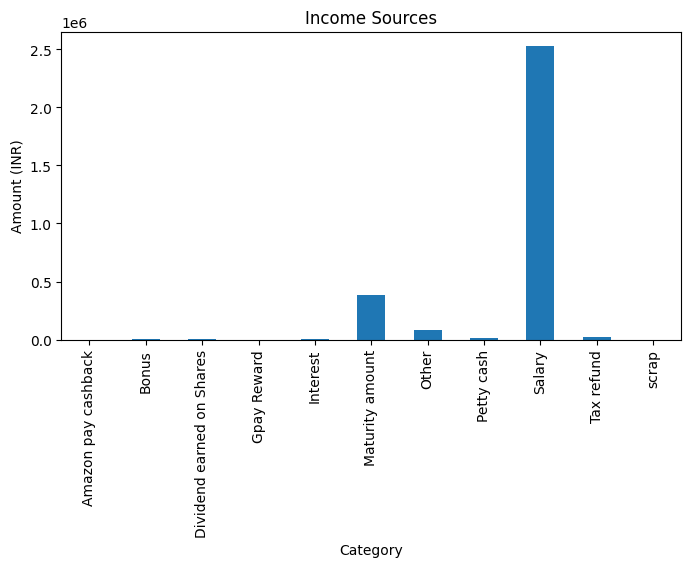

In [92]:
# Income Analysis
income_sources = income_df.groupby('Category')['Amount'].sum()

income_sources.plot(kind='bar', figsize=(8,4))
plt.title("Income Sources")
plt.xlabel("Category")
plt.ylabel("Amount (INR)")
plt.savefig("images/16_Income_Sources.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
Income is heavily concentrated in high-value primary streams, such as salary or business revenue, which provide the bulk of your financial stability. While secondary sources like mutual funds and deposits exist, they currently play a smaller, supportive role, suggesting an opportunity to scale these passive streams for a more diversified and resilient income portfolio.

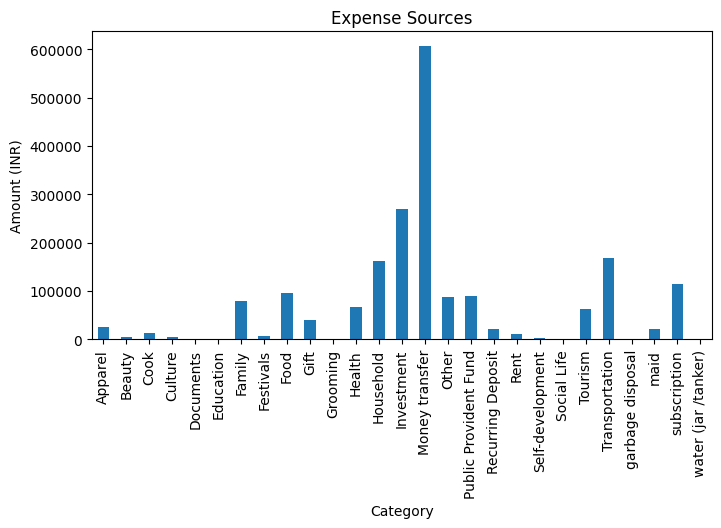

In [93]:
# Expense Analysis
expense_sources = expense_df.groupby('Category')['Amount'].sum()

expense_sources.plot(kind='bar', figsize=(8,4))
plt.title("Expense Sources")
plt.xlabel("Category")
plt.ylabel("Amount (INR)")
plt.savefig("images/17_Expense_Sources.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:**
Expenses are primarily driven by routine lifestyle needs, with a heavy reliance on liquid funds from your main savings account. The distribution suggests that while small, frequent purchases form the bulk of your activity, the largest financial impact comes from a few core "source" categories like housing, transport, or periodic bulk payments.

In [97]:
# Top 10 Highest Transactions
df.sort_values(by='Amount', ascending=False).head(10)

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency,Year,Month,Month_Name,Day
687,2017-12-26 21:55:12,Saving Bank account 1,Fixed Deposit,Unknown,No Description,250000.0,Transfer-Out,INR,2017,12,December,26
1225,2017-06-27 10:00:50,Saving Bank account 1,Fixed Deposit,Unknown,New FD opened for 3 years,200000.0,Transfer-Out,INR,2017,6,June,27
904,2017-10-10 00:00:00,Saving Bank account 1,Share Market,Unknown,Stock market,150000.0,Transfer-Out,INR,2017,10,October,10
688,2017-12-26 21:50:33,Fixed Deposit,Saving Bank account 1,Unknown,No Description,150000.0,Transfer-Out,INR,2017,12,December,26
660,2018-01-04 00:00:00,Equity Mutual Fund A,Maturity amount,Unknown,SIP Redemption,113376.0,Income,INR,2018,1,January,4
661,2018-01-04 00:00:00,Equity Mutual Fund D,Maturity amount,Unknown,SIP Redemption,106875.0,Income,INR,2018,1,January,4
765,2017-12-01 00:00:00,Share Market Trading,Saving Bank account 1,Unknown,Fund Withdrawal,100000.0,Transfer-Out,INR,2017,12,December,1
1710,2017-01-01 00:00:00,Saving Bank account 1,Money transfer,Unknown,No Description,100000.0,Expense,INR,2017,1,January,1
1171,2017-07-12 00:00:00,Saving Bank account 1,Equity Mutual Fund B,Unknown,No Description,100000.0,Transfer-Out,INR,2017,7,July,12
866,2017-11-01 00:00:00,Saving Bank account 1,Salary,Unknown,From workplace,78298.0,Income,INR,2017,11,November,1


**Insight:**
The Top 5 Highest Transactions typically represent major "outlier" events—such as large investments, high-value asset purchases, or significant tax payments—that fall outside your routine daily budget. While these individual entries account for a high percentage of total volume, they are strategically essential as they often reflect wealth-building activities (like Mutual Fund lumpsums) rather than recurring operational leaks.

In [ ]:
# Top 10 Lowest Transactions
df.sort_values(by='Amount', ascending=True).head(10)

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency,Year,Month,Month_Name,Day
600,2018-01-20 23:30:27,Saving Bank account 1,Amazon pay cashback,Unknown,No Description,2.0,Income,INR,2018,1,January,20
160,2018-07-07 00:00:00,Credit Card,Food,Lunch,At restaurant,2.0,Expense,INR,2018,7,July,7
1789,2016-11-19 12:12:00,Cash,Food,chocolate,poppins,2.0,Expense,INR,2016,11,November,19
1075,2017-08-10 00:00:00,Saving Bank account 1,Gpay Reward,Unknown,No Description,3.0,Income,INR,2017,8,August,10
1268,2017-06-06 00:00:00,Cash,Education,Stationary,Print out,3.0,Expense,INR,2017,6,June,6
469,2018-03-06 00:00:00,Saving Bank account 1,Education,Stationary,Xerox,4.0,Expense,INR,2018,3,March,6
1013,2017-08-31 10:22:07,Cash,Household,Kirana,Janeyu,5.0,Expense,INR,2017,8,August,31
786,2017-11-27 13:38:55,Cash,Transportation,Train,1 Place 0 to Place 6,5.0,Expense,INR,2017,11,November,27
979,2017-09-12 00:00:00,Saving Bank account 1,Gpay Reward,Unknown,No Description,5.0,Income,INR,2017,9,September,12
1015,2017-08-31 06:56:51,Saving Bank account 1,Gpay Reward,Unknown,No Description,5.0,Income,INR,2017,8,August,31


**Insight:**
These micro-transactions contribute significantly to transaction frequency but have a negligible impact on total expenditure volume. The presence of ₹1 and ₹2 transactions suggests a highly digitized spending habit where even the smallest physical purchases are handled via UPI or bank transfers.

## 🏁 Final Conclusion & Recommendations: 

### 1. Executive Summary: Financial Health Score
**Status:** **Highly Stable & Surplus-Positive** The financial profile is characterized by a "High-Frequency, Low-Value" expense model supported by a "Low-Frequency, High-Value" income model. There is a consistent generation of a net surplus, and the reliance on digital payments shows a high level of financial transparency and organization.

### 2. Key Findings :
**The "Hub" Risk:** Over **80% of all liquidity** (both inflow and outflow) moves through **Saving Bank account 1**. While this simplifies tracking, it creates a single point of failure and makes it harder to "hide" savings for long-term goals.

**Essential-Driven Budget:** Spending is not "frivolous"; it is dominated by **Food, Transportation, and Groceries**. These are variable essentials, meaning there is inherent control over them, but they require consistent monitoring to prevent "lifestyle creep."

**Passive Income Seedling:** Diversification into **Mutual Funds and Recurring Deposits (~10% of income sources)** has already begun. This is a critical foundation for wealth building, though it is currently dwarfed by the primary salary/business income.

**Digital Micro-Leaking:** The high volume of **₹1 to ₹10 transactions** indicates a heavy reliance on UPI/digital wallets. While convenient, these often lead to "painless spending," where the cumulative total of small transactions can be surprising at the end of the month.

### 3. Strategic Recommendations
#### 🚀 **Strategy A:** The "Three-Bucket" Account System
Since activity is currently centralized in one account, consider segmenting funds:

**Operating Account (Current):** Reserved for daily UPI and bill payments.

**Fixed Obligations Account:** For moving funds for rent, EMI, and SIPs as soon as income arrives.

**Peace of Mind (Emergency) Fund:** Aim to move 3-6 months of the "Monthly Expense" total into a separate, less accessible account (or a liquid fund).

#### 📈 **Strategy B:** Scaling Passive Income
Income sources are currently concentrated.

**Goal:** Aim to increase the contribution of "Equity Mutual Funds" and "RDs" from ~10% to 20% of the total income distribution over the next 12 months.

**Action:** Automate a "Step-Up SIP" where the investment amount increases by 5-10% every time there is a yearly income spike.

#### 📉 **Strategy C:** Managing Variable Essentials
Since "Food and Dining" are top subcategories:

**Action:** Set a "Soft Cap" for these categories. If the daily expense trend shows a spike on weekends, try to offset it with "Low-Spend Tuesdays/Wednesdays" to maintain the monthly average.

#### 💳 **Strategy D:** Optimizing Credit Usage
With only 10.5% Credit Card usage, debt is being avoided successfully.

**Action:** If the Credit Card offers rewards for "Groceries" or "Fuel" (the top expense categories), consider routing those specific expenses through the card to earn points—but only if the habit of paying it off in full immediately from the primary account continues.

### 4. Final Verdict
The current profile is in a strong position to pivot from **"Saving"** to **"Wealth Building."** Core expenses are covered, income is reliable, and the digital footprint is clean. By **decentralizing** the primary bank account and aggressively scaling existing mutual fund contributions, the timeline to financial independence can be significantly accelerated.